In [8]:
from notebooks.summersoc.globals import PATH_METRICS_DEMO_EXPLORE
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('default')

from agent.components import RASK
from agent.components.GaussianProcess import GASK
from agent.components.commons import ServiceType, theoretical_param_bounds, ServiceVar, FIG_SIZE_DEFAULT
from agent.components.commons import SloSet

services = [ServiceType.QR, ServiceType.CV, ServiceType.PC]
slos = [SloSet.DEFAULT, SloSet.HIGH_PERF, SloSet.LOW_COST, SloSet.HIGH_QUALITY]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
df_explore = pd.read_csv(PATH_METRICS_DEMO_EXPLORE)
df_explore_preprocessed = RASK.preprocess_data(df_explore)

INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str


## **Analyze**: Regression Analysis of Structural Knowledge

### Create Structural Knowledge

Purpose is to identify structural dependencies directly from data

Also helps to determine which metrics to track, and for the tracked ones, which resolution to choose.

Please talk to **Nefeli Marina Rouska** if you find this interesting

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered,O=Categorical Ordered)inferred from data: 
 {'cores': 'N', 'throughput': 'N', 'data_quality': 'N'}


  0%|          | 0/1000000 [00:00<?, ?it/s]

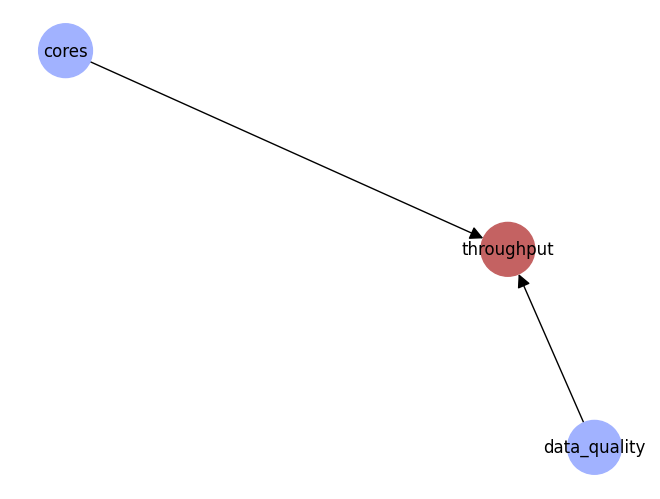

In [3]:
from pgmpy.structure_score import AICGauss
from utils import visualize_DAG

from pgmpy.base import DAG
from pgmpy.causal_discovery import HillClimbSearch

df_filtered = df_explore_preprocessed[df_explore_preprocessed['service_type'] == ServiceType.QR.value]
df_filtered = df_filtered[['cores', 'throughput', 'data_quality']]

scoring_method = AICGauss(data=df_filtered)
estimator = HillClimbSearch(scoring_method=scoring_method)

estimator.fit(X=df_filtered)
dag: DAG = estimator.causal_graph_

regular = '#a1b2ff'  # blue
special = '#c46262'  # red

visualize_DAG(dag, color_map=[regular, special, regular])

### Functional Data Analysis

Note that both variants commonly benefit from removing outliers from the dataset; in our case, it was not needed according to our judgment.

#### Variant 1: Using a Simple Regression Model

Low complexity

No uncertainty

#### Variant 2: Using a Gaussian Process

Medium complexity

Has uncertainty

In [4]:
# import plotly.io as pio
#
# print(pio.renderers)
# pio.renderers.default = "chrome"
# import plotly
# import jupyterlab
#
# print(plotly.__version__)
# print(jupyterlab.__version__)

# for type in ['plotly_mimetype', 'jupyterlab', 'nteract', 'vscode',
#          'notebook', 'notebook_connected', 'kaggle', 'azure', 'colab',
#          'cocalc', 'databricks', 'json', 'png', 'jpeg', 'jpg', 'svg',
#          'pdf', 'browser', 'firefox', 'chrome', 'chromium', 'iframe',
#          'iframe_connected', 'sphinx_gallery', 'sphinx_gallery_png']:

In [5]:
# TODO: Give the option to change between interactive plot and not; the static
#  plot would also always render withing the notebook.

import plotly.io as pio

pio.renderers.default = 'browser'

gp_list = []
lml_history = []

split_data_into_x_parts = 10
iterate_through_x_parts = 10

for i in range(iterate_through_x_parts):
    gp_all_services = {}
    data_ratio = (i + 1) / split_data_into_x_parts
    lml_all_service = []

    for s in services:
        # Initialize and train GP model
        draw_figures = i == (iterate_through_x_parts / 2) - 1 or i == iterate_through_x_parts - 1
        _gp = GASK(s, create_figures=draw_figures, display_figures=draw_figures)
        _gp.init_model(df_explore, data_density=data_ratio)

        _lml = _gp.get_model_lml(s, "max_tp")
        lml_scaled = _lml / data_ratio
        lml_all_service.append(lml_scaled)
        # print(f"Ratio {data_ratio}: LML = {lml:.2f}")
        gp_all_services[s] = _gp

    lml_history.append(lml_all_service)
    gp_list.append(gp_all_services)

    print(f"Finished {i + 1} / {iterate_through_x_parts} of the Gaussian Processes")

lml_history = np.array(lml_history)


INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:GP_Model:Fitting GP for elastic-workbench-qr-detector - Target: max_tp
/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__k1__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
INFO:multiscale:trai

Finished 1 / 10 of the Gaussian Processes


/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__k1__constant_value is close to the specified lower bound 0.001. Decreasing the boun

Finished 2 / 10 of the Gaussian Processes


INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:GP_Model:Fitting GP for elastic-workbench-pc-visualizer - Target: max_tp
/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
INFO:multiscale:train_gp_models took 63 ms to execute
INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:GP_Model:Fitting GP for elastic-workbench-qr-detector - Target: max_tp
/home/boris/development/composable-autonomous-offe

...

Finished 8 / 10 of the Gaussian Processes


/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
INFO:multiscale:train_gp_models took 241 ms to execute
INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:GP_Model:Fitting GP for elastic-workbench-cv-analyzer - Target: max_tp
/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a bett

Finished 9 / 10 of the Gaussian Processes


/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
INFO:multiscale:draw_3d_gp_plot took 773 ms to execute
INFO:multiscale:train_gp_models took 1020 ms to execute
INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:GP_Model:Fitting GP for elastic-workbench-cv-analyzer - Target: max_tp
/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.01. De

Finished 10 / 10 of the Gaussian Processes


#### Create LML Figure

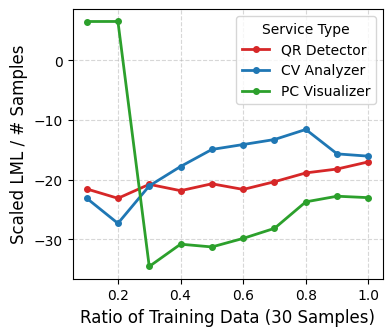

In [6]:
# 1. Define the X-axis (Data Ratios)
data_ratios = np.arange(1, iterate_through_x_parts + 1) / split_data_into_x_parts

# 2. Create the Figure
plt.figure(figsize=FIG_SIZE_DEFAULT)

# Service labels matching your 'services' list order
labels = ['QR Detector', 'CV Analyzer', 'PC Visualizer']
colors = ['#d62728', '#1f77b4', '#2ca02c']  # Red, Blue, Green

for i in range(lml_history.shape[1]):
    plt.plot(data_ratios * (split_data_into_x_parts / iterate_through_x_parts), lml_history[:, i],
             marker='o', markersize=4, linewidth=2,
             label=labels[i], color=colors[i])

# 3. Formatting
abs_samples = int(len(df_explore) * (iterate_through_x_parts / split_data_into_x_parts))
plt.xlabel(f'Ratio of Training Data ({int(abs_samples / 3)} Samples)', fontsize=12)
plt.ylabel('Scaled LML / # Samples', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Service Type")
plt.show()

In [7]:

RUN_HEATMAP = False  # TODO: Does the heatmap provide some benefit?
if RUN_HEATMAP:

    from agent.components.GaussianProcess import get_empirical_variable_bounds
    from utils import visualize_ndarray
    from agent.components.commons import ServiceVar
    from typing import Dict
    from agent.components.Optimizer import VersatileMapElites


    def extract_pfo_for_SLOs(gp_service, slos: Dict[ServiceVar, float], slo_type: str, simple_bounds):
        v_me = VersatileMapElites(gp_service.s_type, bins=8)

        #  I'm getting the black cells because they are not explored.
        #  What I can do is force all cells to be explored at least once,
        #  or just run gradient descent for each cell multiple (like 5) times.
        v_me.run_search(slos, gp_service, simple_bounds, iterations=2000)
        visualize_ndarray(v_me.fitness_table, gp_service.s_type.value + "_" + slo_type, cmap="viridis")


    final_empirical_bounds = get_empirical_variable_bounds(df_explore_preprocessed)[ServiceType.QR]
    simple_param_bounds = final_empirical_bounds.copy()
    del simple_param_bounds[ServiceVar.PERFORMANCE]
    simple_param_bounds = list(simple_param_bounds.values())

    candidate_solutions = []
    # (1) Here I give it increasingly more training data
    for i in range(iterate_through_x_parts):
        candidates = extract_pfo_for_SLOs(gp_list[i][ServiceType.QR], SloSet.DEFAULT.value, "DEFAULT",
                                          simple_param_bounds)
        candidate_solutions.append(candidates)
